# Wildfire Detection from Aerial Imagery V2

This is the file I used to inspect data and create the functions of the pipeline I later moved into python files to use in different ipynb.




## Setup & Imports

In [ ]:
%load_ext autoreload
%autoreload 2


import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Machine Learning libraries (with all necessary imports in each file)
import utils as ml_utils
import config as ml_config
import model as ml_model

# TensorFlow and Keras
import tensorflow as tf
from sklearn.metrics import ( precision_recall_curve, classification_report, precision_score, recall_score, f1_score
)

# Reproducibility
random.seed(ml_config.SEED)
np.random.seed(ml_config.SEED)
tf.random.set_seed(ml_config.SEED)
AUTOTUNE = tf.data.AUTOTUNE


print("TensorFlow:", tf.__version__)


TensorFlow: 2.16.1
GPU available: False


## I- Dataset Exploration

In [ ]:
train_counts = ml_utils.count_images(ml_config.TRAIN_DIR)
test_counts  = ml_utils.count_images(ml_config.TEST_DIR)

# Identify lake frames within No_Fire
train_nofire_files = list((ml_config.TRAIN_DIR / "No_Fire").glob("*.jpg"))
n_lake_train = sum(1 for f in train_nofire_files if f.name.startswith("lake"))
n_nofire_train = len(train_nofire_files) - n_lake_train

test_nofire_files  = list((ml_config.TEST_DIR / "No_Fire").glob("*.jpg"))
n_lake_test  = sum(1 for f in test_nofire_files if f.name.startswith("lake"))
n_nofire_test = len(test_nofire_files) - n_lake_test

summary = pd.DataFrame({
    "Split":    ["Train", "Train", "Train", "Test", "Test", "Test"],
    "Class":    ["Fire",  "No Fire (non-lake)", "No Fire (lake)",
                 "Fire",  "No Fire (non-lake)", "No Fire (lake)"],
    "Count":    [train_counts["Fire"], n_nofire_train, n_lake_train,
                 test_counts["Fire"],  n_nofire_test,  n_lake_test],
})
print(summary.to_string(index=False))
print(f"\nTotal train: {sum(train_counts.values()):,}  |  Total test: {sum(test_counts.values()):,}")


Split              Class  Count
Train               Fire  25018
Train No Fire (non-lake)   2510
Train     No Fire (lake)  11847
 Test               Fire   5137
 Test No Fire (non-lake)   3480
 Test     No Fire (lake)      0

Total train: 39,375  |  Total test: 8,617


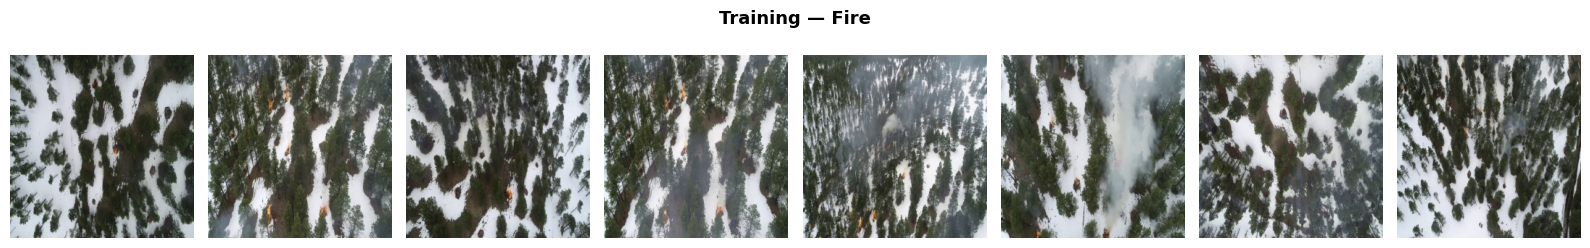

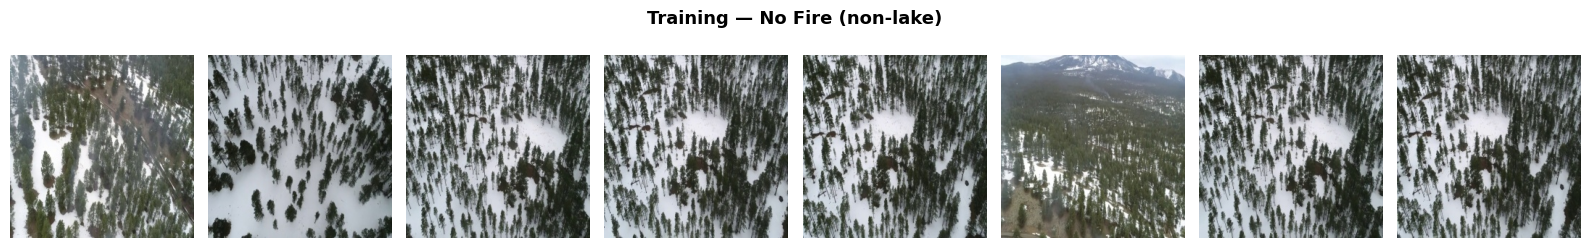

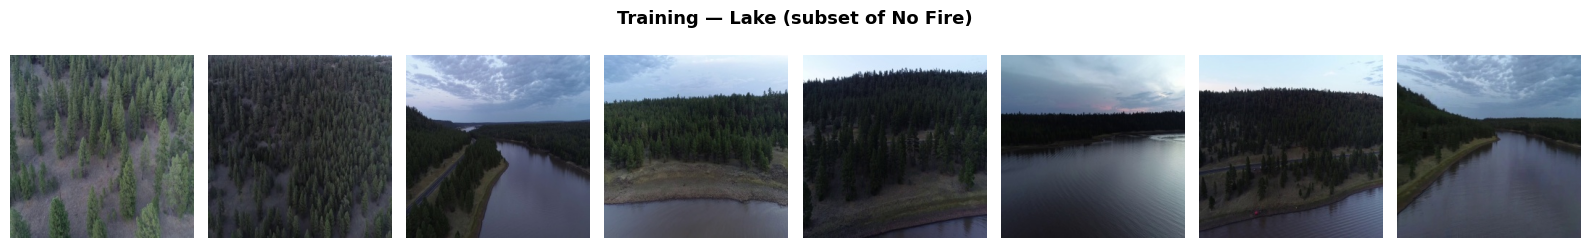

In [ ]:
def show_samples(paths, title, n=8):
    """
    Display a random grid of sample images from a list of file paths.

    Parameters
    ----------
    paths : list[str | Path]
        File paths to candidate images.  Must contain at least ``n``
        entries; a :class:`ValueError` is raised by ``random.sample`` if
        fewer are available.
    title : str
        Super-title rendered above the image grid in bold (font size 13).
    n : int, optional
        Number of images to sample and display.  Defaults to ``8``.

    Returns
    -------
    None
        Displays the figure inline (e.g. in a Jupyter notebook) and does
        not return a value.

    """
    fig, axes = plt.subplots(1, n, figsize=(2*n, 2.5))
    for ax, p in zip(axes, random.sample(paths, n)):
        ax.imshow(Image.open(p))
        ax.axis("off")
    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

fire_paths  = list((ml_config.TRAIN_DIR / "Fire").glob("*.jpg"))
nofire_paths = [f for f in train_nofire_files if not f.name.startswith("lake")]
lake_paths   = [f for f in train_nofire_files if f.name.startswith("lake")]

show_samples(fire_paths,   "Training — Fire")
show_samples(nofire_paths, "Training — No Fire (non-lake)")
show_samples(lake_paths,   "Training — Lake (subset of No Fire)")


## II- Perceptual Deduplication

- Hash threshold ≤ 4 bits difference =>treated as duplicate
- Applied to training Fire and No_Fire and lkae separetely
- Test set is left untouched 


In [ ]:

print("Deduplicating Fire frames …")
fire_sorted   = sorted(fire_paths,   key=ml_config.frame_number)
fire_deduped  = ml_config.deduplicate(fire_sorted)

print("Deduplicating No Fire (non-lake) frames …")
nofire_sorted  = sorted(nofire_paths,  key=ml_config.frame_number)
nofire_deduped = ml_config.deduplicate(nofire_sorted)

print("Deduplicating Lake frames …")
lake_sorted   = sorted(lake_paths,   key=ml_config.frame_number)
lake_deduped  = ml_config.deduplicate(lake_sorted)

print(f"\nFire:    {len(fire_paths):>6,}  →  {len(fire_deduped):>6,}  "
      f"({100*(1-len(fire_deduped)/len(fire_paths)):.1f}% removed)")
print(f"No Fire: {len(nofire_paths):>6,}  →  {len(nofire_deduped):>6,}  "
      f"({100*(1-len(nofire_deduped)/len(nofire_paths)):.1f}% removed)")
print(f"Lake:    {len(lake_paths):>6,}  →  {len(lake_deduped):>6,}  "
      f"({100*(1-len(lake_deduped)/len(lake_paths)):.1f}% removed)")


Deduplicating Fire frames …
Deduplicating No Fire (non-lake) frames …
Deduplicating Lake frames …

Fire:    25,018  →   1,913  (92.4% removed)
No Fire:  2,510  →     566  (77.5% removed)
Lake:    11,847  →     995  (91.6% removed)


## III- Data Preparation


To avoid leakage from temporally correlated frames we split by **frame-number blocks**:
frames are sorted by index, then every 5th contiguous block is assigned to validation.
This ensures no two adjacent frames straddle the boundary differently from a random split.


In [ ]:


fire_train,   fire_val   = ml_config.temporal_split(fire_deduped)
nofire_train, nofire_val = ml_config.temporal_split(nofire_deduped)
lake_train,   lake_val   = ml_config.temporal_split(lake_deduped)

print("After deduplication + temporal split:")
print(f"  Fire    — train: {len(fire_train):>5,}  val: {len(fire_val):>4,}")
print(f"  No Fire — train: {len(nofire_train):>5,}  val: {len(nofire_val):>4,}")
print(f"  Lake    — train: {len(lake_train):>5,}  val: {len(lake_val):>4,}")


After deduplication + temporal split:
  Fire    — train: 1,640  val:  273
  No Fire — train:   486  val:   80
  Lake    — train:   853  val:  142


###  Building the datasets (includes lakes in No_Fire)


Augmentation (applied only during training): horizontal flip, vertical flip, random brightness, random contrast.


In [ ]:
# Building data sets for binary classification (Fire vs No Fire, with lakes grouped into No Fire)
bin_train_ds, bin_val_ds, bin_test_ds, bin_train_labels, bin_val_labels,bin_test_labels = (
        ml_utils.build_binary_datasets(fire_deduped, nofire_deduped, lake_deduped, lake_as_nofire=True)
)

# class weight to handle Fire >> No-Fire imbalance
n_fire   = bin_train_labels.count(1)
n_nofire = bin_train_labels.count(0)
total    = n_fire + n_nofire
binary_class_weights = {0: total / (2 * n_nofire),
                        1: total / (2 * n_fire)}
print("Binary class weights:", {k: f"{v:.3f}" for k, v in binary_class_weights.items()})
print(f"Binary train batches: {len(bin_train_ds)}  |  val: {len(bin_val_ds)}  |  test: {len(bin_test_ds)}")


Binary class weights: {0: '1.112', 1: '0.908'}
Binary train batches: 94  |  val: 16  |  test: 270


## IV - Binary Model (V2)


### A) Model Training

In [ ]:
micro_cnn_binary = ml_model.binary_micro_cnn()
micro_cnn_binary.summary()

history_micro_cnn_binary = micro_cnn_binary.fit(
    bin_train_ds,
    validation_data=bin_val_ds,
    epochs=100,
    class_weight=binary_class_weights,
    callbacks=ml_config.callbacks_binary_cnn_v2,
    verbose=1,
)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 254, 254, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 127, 127, 8)    │           216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 127, 127, 8)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 127, 127, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_12             │ (None, 127, 127, 8)    │            72 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 127, 127, 8)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 127, 127, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 127, 127, 16)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 127, 127, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_29 (Activation)      │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_12            │ (None, 63, 63, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_13             │ (None, 63, 63, 16)     │           144 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 63, 63, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_30 (Activation)      │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 63, 63, 32)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 63, 63, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_31 (Activation)      │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_13            │ (None, 31, 31, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 11,569 (45.19 KB)

 Trainable params: 10,897 (42.57 KB)

 Non-trainable params: 672 (2.62 KB)

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 17s 147ms/step - accuracy: 0.7751 - auc: 0.8442 - loss: 0.1349 - precision: 0.8077 - recall: 0.7762 - val_accuracy: 0.4485 - val_auc: 0.5000 - val_loss: 0.2152 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 142ms/step - accuracy: 0.8604 - auc: 0.9257 - loss: 0.0887 - precision: 0.8673 - recall: 0.8811 - val_accuracy: 0.4485 - val_auc: 0.4507 - val_loss: 0.4710 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 155ms/step - accuracy: 0.8755 - auc: 0.9378 - loss: 0.0811 - precision: 0.8779 - recall: 0.8988 - val_accuracy: 0.4485 - val_auc: 0.8457 - val_loss: 0.8209 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/100
93/94 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.8836 - auc: 0.9491 - loss: 0.0735 - precision: 0.8979 - recall: 0.8932
Epoch 4: ReduceLROnPlateau reducin

### B) Training Curves

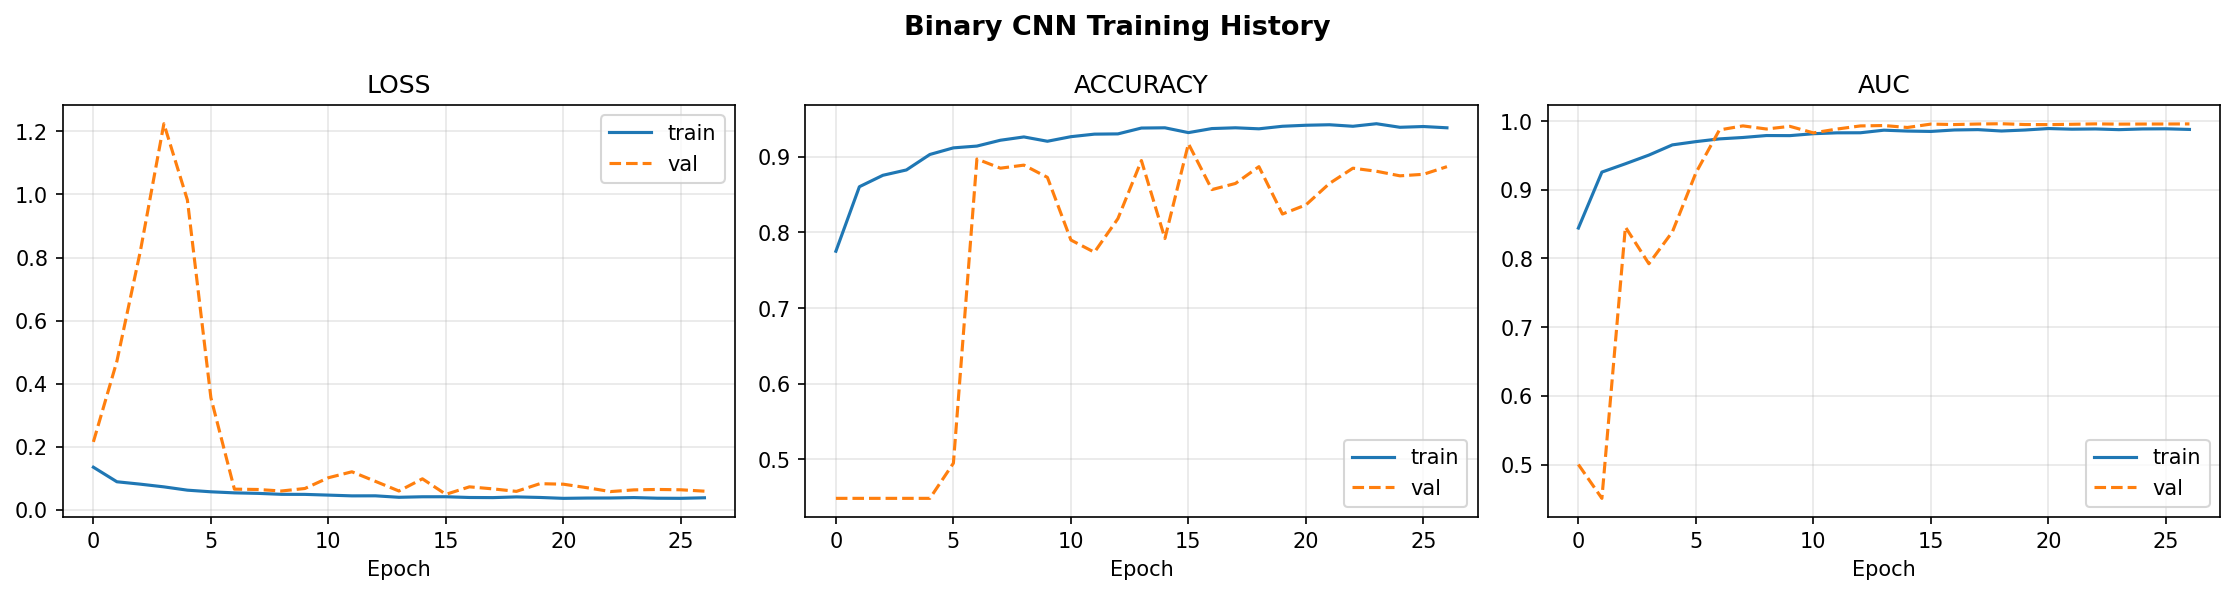

In [ ]:

ml_utils.plot_history(history_micro_cnn_binary,    "Binary V2 Training History")


**Comment:**  early stopping was triggered at epoch 27 based on validation AUC, and the model was restored to the best model at epoch 19.  

### C) Evaluation


  Binary V1 Confusion Matrix (Val)
              precision    recall  f1-score   support

     No Fire       0.59      1.00      0.74        80
        Fire       1.00      0.79      0.89       273

    accuracy                           0.84       353
   macro avg       0.79      0.90      0.81       353
weighted avg       0.91      0.84      0.85       353

AUC: 0.9891


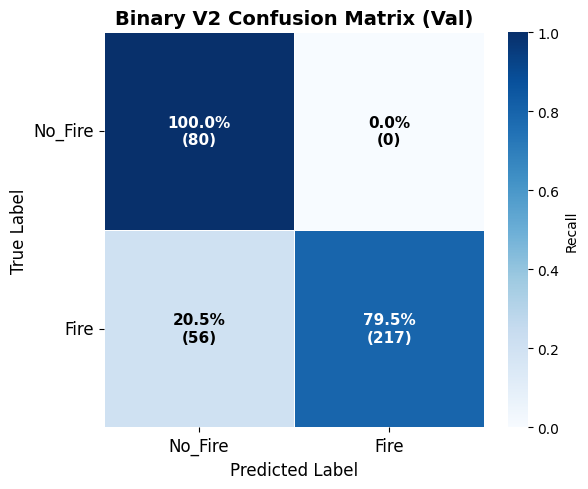

In [166]:
results_binary_val = []
results_binary_val.append(ml_utils.evaluate_binary(micro_cnn_binary,      bin_val_ds,
                                       bin_val_labels, "Binary V1 Confusion Matrix (Val)"))

ml_utils.plot_confusion_matrix(results_binary_val[0][0],results_binary_val[0][1],['No_Fire','Fire'], title="Binary V2 Confusion Matrix (Val)")

**Comment:** The model tends to predict Fire more liberally, resulting in more false positives than false negatives. In a wildfire detection context this is the preferable error => missing a real fire carries far greater risk than a spurious alert. That said, the validation set is small, so these results should be treated as indicative rather than a definitive measure of generalisation performance.

In [ ]:

results_binary = []


results_binary.append(ml_utils.evaluate_binary(micro_cnn_binary,      bin_test_ds,
                                       bin_test_labels, "Binary V1 Confusion Matrix (test)"))

ml_utils.plot_confusion_matrix(results_binary[0][0],results_binary[0][1],['No_Fire','Fire'], title="Binary V2 Confusion Matrix (test)")


  Binary V1 Confusion Matrix (test)
              precision    recall  f1-score   support

     No Fire       0.72      0.80      0.75      3480
        Fire       0.85      0.79      0.82      5137

    accuracy                           0.79      8617
   macro avg       0.78      0.79      0.79      8617
weighted avg       0.80      0.79      0.79      8617

AUC: 0.8319


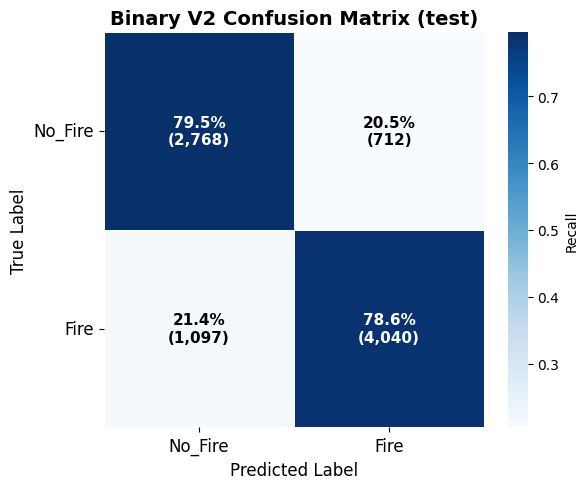

In [142]:
ml_utils.plot_confusion_matrix(results_binary[0][0],results_binary[0][1],['No_Fire','Fire'], title="Binary V2 Confusion Matrix (test)")

**Comment:** We see that there are a 20% of Fire predicted as no Fire, this would lead to many fire considered as no fire which is very dangerous

### D) Treshold Tuning

In [ ]:
val_true  = np.array(bin_val_labels)
val_scores = micro_cnn_binary.predict(bin_val_ds).flatten()

print(f"val_scores: {len(val_scores)}")  # should be 353
print(f"val_true:   {len(val_true)}")    # should be 353

# Threshold tuning on VALIDATION set
prec_curve, rec_curve, pr_thresholds = precision_recall_curve(val_true, val_scores)

#  Max F1
f1_curve  = (2 * prec_curve[:-1] * rec_curve[:-1]
             / np.maximum(prec_curve[:-1] + rec_curve[:-1], 1e-9))
best_t_f1 = pr_thresholds[np.argmax(f1_curve)]

#  Max recall @ precision >= 0.70
MIN_PREC  = 0.70
mask      = prec_curve[:-1] >= MIN_PREC
if not mask.any():
    raise ValueError(
        f"No threshold on the validation set achieves precision >= {MIN_PREC}. "
        "Lower MIN_PREC or improve the model."
    )
best_t_recall = pr_thresholds[mask][np.argmax(rec_curve[:-1][mask])]

print(f"Best F1 threshold     (val): {best_t_f1:.4f}")
print(f"Best recall threshold (val): {best_t_recall:.4f}")

# Evaluate on TEST set
y_true   = np.array(bin_test_labels)
y_scores = micro_cnn_binary.predict(bin_test_ds).flatten()

for name, t in [("Max F1", best_t_f1), ("Max Recall @p≥0.70", best_t_recall)]:
    y_pred = (y_scores >= t).astype(int)
    print(f"\n── {name}  (t={t:.4f})  on TEST set")
    print(classification_report(y_true, y_pred,
                                target_names=["No Fire", "Fire"], digits=3))


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
val_scores: 353
val_true:   353
Best F1 threshold     (val): 0.3407
Best recall threshold (val): 0.0070
270/270 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step

── Max F1  (t=0.3407)  on TEST set
              precision    recall  f1-score   support

     No Fire      0.710     0.626     0.666      3480
        Fire      0.766     0.827     0.795      5137

    accuracy                          0.746      8617
   macro avg      0.738     0.727     0.730      8617
weighted avg      0.743     0.746     0.743      8617


── Max Recall @p≥0.70  (t=0.0070)  on TEST set
              precision    recall  f1-score   support

     No Fire      1.000     0.024     0.046      3480
        Fire      0.602     1.000     0.751      5137

    accuracy                          0.606      8617
   macro avg      0.801     0.512     0.399      8617
weighted avg      0.763     0.606     0.467      8617



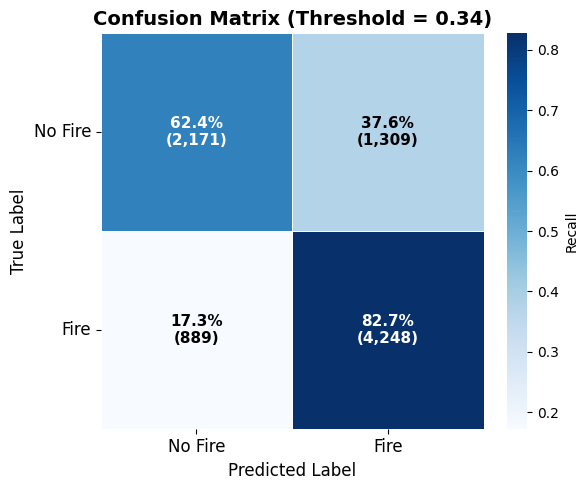

In [171]:
y_pred = (y_scores > 0.34).astype(int).flatten()

ml_utils.plot_confusion_matrix(
    y_true=bin_test_labels,
    y_pred=y_pred,
    class_names=["No Fire", "Fire"],
    title="Confusion Matrix (Threshold = 0.34)"
)

### E) Consecutive filter tuning

In [92]:
def consecutive_filter(y_scores, threshold=0.27, n_consecutive=3, window=5):
    """
    A detection is only raised if at least `n_consecutive` frames
    out of the last `window` frames exceed the threshold.
    Simulates temporal filtering on a sequence of images.
    """
    binary = (y_scores >= threshold).astype(int)
    filtered = np.zeros_like(binary)

    for i in range(len(binary)):
        window_slice = binary[max(0, i - window + 1) : i + 1]
        if window_slice.sum() >= n_consecutive:
            filtered[i] = 1

    return filtered

In [ ]:
window = 5
results = []
y_scores= micro_cnn_binary.predict(bin_val_ds).flatten()  # predicted probabilities

# sweep through different values of n_consecutive to see how it affects precision, recall, F1, FP, and FN
for n in range(1, window + 1):
    y_filtered = consecutive_filter(y_scores, threshold=0.27,
                                    n_consecutive=n, window=window)
    prec = precision_score(bin_val_labels, y_filtered)
    rec  = recall_score(bin_val_labels, y_filtered)
    f1   = f1_score(bin_val_labels, y_filtered)
    fp   = ((y_filtered == 1) & (bin_val_labels == 0)).sum()
    fn   = ((y_filtered == 0) & (bin_val_labels == 1)).sum()
    results.append(dict(n=n, precision=prec, recall=rec, f1=f1, FP=fp, FN=fn))
    print(f"N={n}  precision={prec:.3f}  recall={rec:.3f}  "
          f"f1={f1:.3f}  FP={fp}  FN={fn}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
N=1  precision=0.840  recall=1.000  f1=0.913  FP=0  FN=0
N=2  precision=0.863  recall=0.996  f1=0.925  FP=0  FN=0
N=3  precision=0.900  recall=0.993  f1=0.944  FP=0  FN=0
N=4  precision=0.941  recall=0.989  f1=0.964  FP=0  FN=0
N=5  precision=0.957  recall=0.967  f1=0.962  FP=0  FN=0


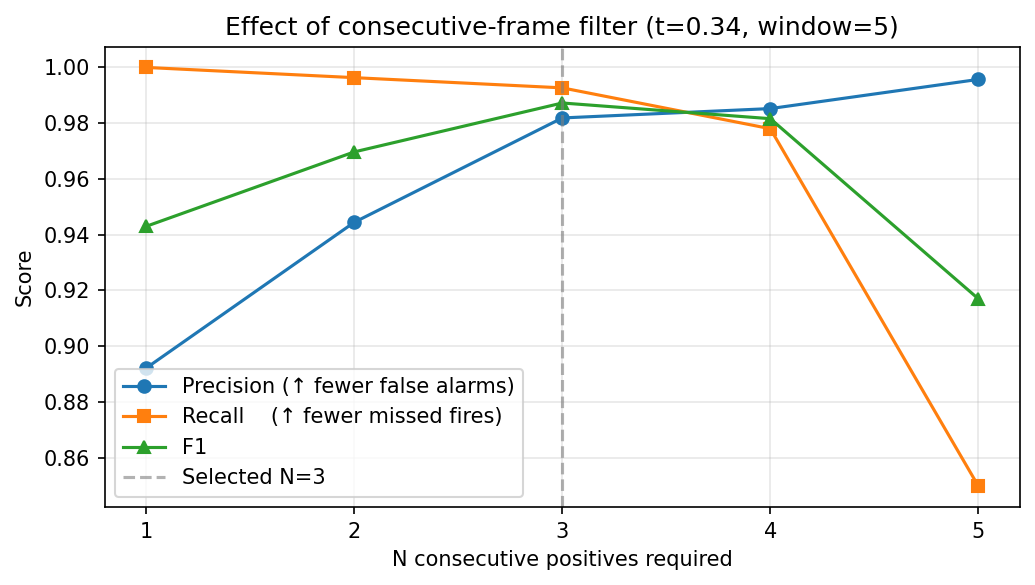

In [ ]:
# obtaining lists for plotting
ns         = [r["n"]         for r in results]
precisions = [r["precision"] for r in results]
recalls    = [r["recall"]    for r in results]
f1s        = [r["f1"]        for r in results]

# plotting the effect of N on precision, recall, and F1
fig, ax = plt.subplots(figsize=(7, 4), dpi=150)
ax.plot(ns, precisions, "o-", label="Precision (↑ fewer false alarms)")
ax.plot(ns, recalls,    "s-", label="Recall    (↑ fewer missed fires)")
ax.plot(ns, f1s,        "^-", label="F1")

# Mark N=3 as the chosen operating point
ax.axvline(x=3, color="grey", linestyle="--", alpha=0.6, label="Selected N=3")

ax.set_xlabel("N consecutive positives required")
ax.set_ylabel("Score")
ax.set_title("Effect of consecutive-frame filter (t=0.34, window=5)")
ax.set_xticks(ns)
ax.legend()
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Sweep N on VALIDATION set
window  = 5
results = []

for n in range(1, window + 1):
    y_filtered = consecutive_filter(val_scores, threshold=0.34,
                                    n_consecutive=n, window=window)
    prec = precision_score(val_true, y_filtered)
    rec  = recall_score(val_true, y_filtered)
    f1   = f1_score(val_true, y_filtered)
    fp   = ((y_filtered == 1) & (val_true == 0)).sum()
    fn   = ((y_filtered == 0) & (val_true == 1)).sum()
    results.append(dict(n=n, precision=prec, recall=rec, f1=f1, FP=fp, FN=fn))
    print(f"N={n}  precision={prec:.3f}  recall={rec:.3f}  "
          f"f1={f1:.3f}  FP={fp}  FN={fn}")

# Pick best N from sweep, then apply to TEST set once


best_n = 3 # this is changed best on sweep results

y_test_scores  = micro_cnn_binary.predict(bin_test_ds).flatten()
y_test_true    = np.array(bin_test_labels)
y_filtered_test = consecutive_filter(y_test_scores, threshold=0.34,
                                     n_consecutive=best_n, window=window)

print(f"\nFinal results on TEST set (t=0.34, N={best_n}):")
print(classification_report(y_test_true, y_filtered_test,
                             target_names=["No Fire", "Fire"]))

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
N=1  precision=0.892  recall=1.000  f1=0.943  FP=33  FN=0
N=2  precision=0.944  recall=0.996  f1=0.970  FP=16  FN=1
N=3  precision=0.982  recall=0.993  f1=0.987  FP=5  FN=2
N=4  precision=0.985  recall=0.978  f1=0.982  FP=4  FN=6
N=5  precision=0.996  recall=0.850  f1=0.917  FP=1  FN=41
270/270 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step

Final results on TEST set (t=0.34, N=3):
              precision    recall  f1-score   support

     No Fire       0.94      0.70      0.81      3480
        Fire       0.83      0.97      0.89      5137

    accuracy                           0.86      8617
   macro avg       0.89      0.84      0.85      8617
weighted avg       0.87      0.86      0.86      8617



270/270 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step
FN (missed fires):  149
FP (false alarms):  1035


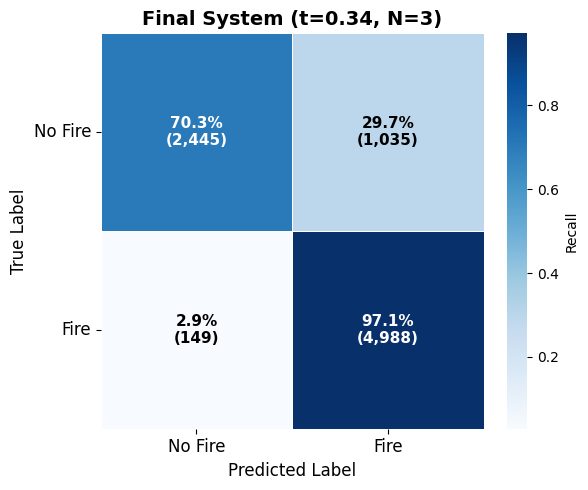

In [ ]:
# Recompute y_filtered with exact settings
y_test_scores = micro_cnn_binary.predict(bin_test_ds).flatten()
y_test_true   = np.array(bin_test_labels)

y_filtered_test = consecutive_filter(y_test_scores, threshold=0.34,
                                     n_consecutive=3, window=5)

# Verify counts match the classification report
print(f"FN (missed fires):  {((y_filtered_test == 0) & (y_test_true == 1)).sum()}")
print(f"FP (false alarms):  {((y_filtered_test == 1) & (y_test_true == 0)).sum()}")



# Plot the correct confusion matrix
ml_utils.plot_confusion_matrix(y_test_true, y_filtered_test,
                      class_names=["No Fire", "Fire"],
                      title="Confusion Matrix (t=0.34, N=3)")